<a href="https://colab.research.google.com/github/Wistoo/2026-CS420-01/blob/main/Assignment_1_SLCM_Data_Exploration_Corrections.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 1: SLCM Data Exploration Corrections
## Wiston Htoo
## CS-430-01
## 9/17/2026

# **Goal**
###### The purpose of this first assignment is to become familiar with a real community dataset and practice the complete early data-analysis workflow: load the data, understand the variables, investigate data quality, clean the data, visualize patterns, and interpret what you see. Most questions are guided. At the end, you will ask one question of your own and use the data to investigate it.

##### **Notebook Instructions**
Copy each numbered question below into a Markdown cell before answering it.
Use a code cell directly below the Markdown question when code is needed.
After important outputs and every visualization, add a short Markdown interpretation in your own words.
Keep useful outputs visible in the submitted notebook.
Create a cleaned copy of the DataFrame rather than overwriting the original data.

##**Part 1 – Get to Know the Dataset**

1. Load the CSV file into pandas. What are the

*   List item
*   List item

dimensions of the dataset?

In [61]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Collab Notebooks/Module 1/SLCM_Basic_Needs_Class_Practice.csv')

In [62]:
# Display the first 5 rows.
df.head()

,Housing_Status,Monthly_Housing_Cost,Moves_Last_3_Years,Utility_Disconnection_Risk,Monthly_LGE_Bill,Monthly_Water_Bill,Eviction_Record,Transportation_Need_Score,Has_Car,Bus_Use
0,Renter - past due rent,1200.0,0,Yes,225.0,200.0,No,1,Yes,Never
1,Renter - past due rent,0.0,1,No,217.0,144.0,No,2,Yes,Never
2,Staying with friends or family,800.0,4,No,100.0,100.0,No,5,Yes,Sometimes
3,Homeless,0.0,2,No,0.0,0.0,Yes,0,Yes,Never
4,Homeless,0.0,3,No,0.0,0.0,Yes,3,Yes,Rarely


In [63]:
# Report the number of rows and columns.
df.shape

(166, 10)

2. What variables are available?

In [64]:
# Print the column names.
df.columns

Index(['Housing_Status', 'Monthly_Housing_Cost', 'Moves_Last_3_Years',
       'Utility_Disconnection_Risk', 'Monthly_LGE_Bill', 'Monthly_Water_Bill',
       'Eviction_Record', 'Transportation_Need_Score', 'Has_Car', 'Bus_Use'],
      dtype='object')

**For each variable, write one short sentence describing what you think it represents.**

* **Housing_Status**: Describes the current living situation of the individual, such as renting or being homeless.
* **Monthly_Housing_Cost**: The total amount of money the individual spends on housing each month.
* **Moves_Last_3_Years**: The number of times the person has changed their residence over the past three years.
* **Utility_Disconnection_Risk**: Indicates whether the individual is currently at risk of having their utilities shut off.
* **Monthly_LGE_Bill**: The typical amount the person pays for their monthly gas and electric (LG&E) utility bill.
* **Monthly_Water_Bill**: The typical amount the person pays for their monthly water bill.
* **Eviction_Record**: Indicates whether the person has a past history of eviction from a residence.
* **Transportation_Need_Score**: A numerical score representing the level of need or difficulty the person faces regarding transportation.
* **Has_Car**: Indicates whether the individual owns or has reliable access to a personal vehicle.
* **Bus_Use**: Describes how frequently the person utilizes the public bus system for transportation.

3. What data types did pandas assign to the variables?

In [65]:
# Use info() and/or dtypes.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 166 entries, 0 to 165
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Housing_Status              166 non-null    object 
 1   Monthly_Housing_Cost        166 non-null    float64
 2   Moves_Last_3_Years          166 non-null    object 
 3   Utility_Disconnection_Risk  166 non-null    object 
 4   Monthly_LGE_Bill            166 non-null    float64
 5   Monthly_Water_Bill          166 non-null    float64
 6   Eviction_Record             166 non-null    object 
 7   Transportation_Need_Score   166 non-null    int64  
 8   Has_Car                     166 non-null    object 
 9   Bus_Use                     166 non-null    object 
dtypes: float64(3), int64(1), object(6)
memory usage: 13.1+ KB


**Which columns are numeric?**

Numeric columns: `Monthly_Housing_Cost`,
`Monthly_LGE_Bill`, `Monthly_Water_Bill` (float64), and `Transportation_Need_Score` (int64).

**Which columns are categorical/object?**

Categorical/Object columns: `Housing_Status`, `Moves_Last_3_Years`, `Utility_Disconnection_Risk`, `Eviction_Record`, `Has_Car`, and `Bus_Use`.

**Does any column have a data type that makes you want to inspect it more closely? Explain.**

`Moves_Last_3_Years` column is assigned an `object` data type, but logically it represents a count (a number). The fact that pandas treated it as an object suggests it might contain non-numeric string values (like "3+" or "Unknown") or invisible characters that need to be cleaned so it can be used as a proper numeric variable.

4. What values occur in each categorical variable?

In [66]:
# Use value_counts() for Housing_Status, Utility_Disconnection_Risk, Eviction_Record, Has_Car, Bus_Use, and Moves_Last_3_Years.
df[['Housing_Status', 'Utility_Disconnection_Risk' , 'Eviction_Record' , 'Has_Car', 'Bus_Use', 'Moves_Last_3_Years']].value_counts()

Housing_Status                                        Utility_Disconnection_Risk  Eviction_Record  Has_Car  Bus_Use    Moves_Last_3_Years
Renter - no rent past due                             No                          Yes              Yes      Never      1                     4
Renter - past due rent                                No                          No               Yes      Never      1                     4
Renter - no rent past due                             No                          No               Yes      Never      0                     3
Staying at extended stay hotel or short-term housing  No                          No               No       Often      3                     3
                                                                                  Yes              No       Often      2                     3
                                                                                                                                            ..
Staying with friends or family                        No                          No               Yes      Never      More than 5           1
                                                                                                            Sometimes  4                     1
                                                                                  Yes              Yes      Never      2                     1
                                                      Yes                         No               No       Sometimes  4                     1
                                                                                  Yes              No       Never      4                     1
Name: count, Length: 127, dtype: int64

In [67]:
# Which categories are most common?
df[['Housing_Status', 'Utility_Disconnection_Risk' , 'Eviction_Record' , 'Has_Car', 'Bus_Use', 'Moves_Last_3_Years']].value_counts().idxmax()

('Renter - no rent past due', 'No', 'Yes', 'Yes', 'Never', '1')

In [68]:
cols_to_check = ['Eviction_Record', 'Has_Car', 'Bus_Use', 'Moves_Last_3_Years']
for col in cols_to_check:
    print(f"--- {col} ---")
    print(df[col].value_counts(dropna=False))
    print()

--- Eviction_Record ---
Eviction_Record
No          114
Yes          42
Not sure     10
Name: count, dtype: int64

--- Has_Car ---
Has_Car
Yes    87
No     79
Name: count, dtype: int64

--- Bus_Use ---
Bus_Use
Never        66
Often        47
Sometimes    35
Rarely       18
Name: count, dtype: int64

--- Moves_Last_3_Years ---
Moves_Last_3_Years
1              43
2              40
0              34
3              20
More than 5    15
4              10
5               4
Name: count, dtype: int64



**Do you notice any values that may need clarification or cleaning?**

Yes. The Moves_Last_3_Years column contains the string value 'More than 5'. This prevents pandas from treating the column as a numeric data type, which makes it harder to use in calculations or certain visualizations. This value will need to be cleaned or recoded (for example, to 5 or 6, or keeping it as a category) depending on the analysis. Additionally, Eviction_Record has 'Not sure' responses which might need to be treated as missing data or grouped depending on the goal.

# **Part 2 – Investigate Data Quality**

5. Are there missing values or duplicate rows?

In [69]:
# Calculate the number of missing values in every column.
df.isnull().sum()

,0
Housing_Status,0
Monthly_Housing_Cost,0
Moves_Last_3_Years,0
Utility_Disconnection_Risk,0
Monthly_LGE_Bill,0
Monthly_Water_Bill,0
Eviction_Record,0
Transportation_Need_Score,0
Has_Car,0
Bus_Use,0


In [70]:
# Check for duplicate rows.
df.duplicated().sum()

np.int64(1)

**Report what you find.**

Based on the checks:

Missing Values: There are no missing values (NaN or nulls) in any of the columns.
Duplicate Rows: There is exactly 1 duplicate row in the dataset.

6. What do the numeric variables look like?

In [71]:
# Use describe() for Monthly_Housing_Cost, Monthly_LGE_Bill, Monthly_Water_Bill, and Transportation_Need_Score.
df[['Monthly_Housing_Cost', 'Monthly_LGE_Bill', 'Monthly_Water_Bill', 'Transportation_Need_Score']].describe()

,Monthly_Housing_Cost,Monthly_LGE_Bill,Monthly_Water_Bill,Transportation_Need_Score
count,166.000000,166.000000,166.000000,166.000000
mean,625.209181,420.003320,42.167815,2.433735
std,560.109409,3587.214867,99.524462,1.796918
min,0.000000,0.000000,0.000000,0.000000
25%,0.010000,0.010000,0.000000,1.000000
50%,550.000000,120.000000,0.010000,3.000000
75%,1100.000000,200.000000,60.000000,4.000000
max,2000.000000,46247.000000,1000.000000,5.000000


In [72]:
# For each variable, identify its minimum, maximum, and typical values.
df[['Monthly_Housing_Cost', 'Monthly_LGE_Bill', 'Monthly_Water_Bill', 'Transportation_Need_Score']].agg(['min', 'max', 'mean'])

,Monthly_Housing_Cost,Monthly_LGE_Bill,Monthly_Water_Bill,Transportation_Need_Score
min,0.000000,0.00000,0.000000,0.000000
max,2000.000000,46247.00000,1000.000000,5.000000
mean,625.209181,420.00332,42.167815,2.433735


**Which values look unusual or deserve a closer look?**

Monthly_LGE_Bill: The maximum value of 46,247 is extremely high for a typical monthly bill and looks like a data entry error or an anomaly.

Monthly_Housing_Cost, Monthly_LGE_Bill, and Monthly_Water_Bill: The minimum value for all of these is 0. While it's possible someone has zero housing costs (e.g., homeless) or utilities included in rent, zero can sometimes be a placeholder for missing data, so it deserves a closer look.

Moves_Last_3_Years: As noted earlier, this column contains the text value 'More than 5', which makes it an object data type rather than a standard numeric count.

7. Investigate zero values.

In [73]:
# Count how many records have Monthly_Housing_Cost = 0.
df[df['Monthly_Housing_Cost'] == 0].shape[0]

31

In [74]:
# Count how many records have Monthly_LGE_Bill = 0 and Monthly_Water_Bill = 0.
(df['Monthly_LGE_Bill'] == 0).sum() + (df['Monthly_Water_Bill'] == 0).sum()

np.int64(105)

In [75]:
# Look at Housing_Status for records with Monthly_Housing_Cost = 0.
df[df['Monthly_Housing_Cost'] == 0]['Housing_Status'].value_counts()

,count
Housing_Status,
Renter - no rent past due,14
Homeless,13
Staying with friends or family,2
Renter - past due rent,1
Staying at extended stay hotel or short-term housing,1


**Does a zero always appear to mean "bad data"? Explain what else zero could reasonably mean in this dataset.**

No, a zero does not always mean "bad data" in this dataset. For instance, we saw that many of the people with  0 in Monthly Housing Cost have a Housing Status of "Homeless" or are "Staying with friends or family "which genuinely means they don′t pay for housing.

Similarly,a 0 Monthly_LGE_Bill or Monthly_Water_Bill could legitimately mean that those utilities are included in their rent, or perhaps covered by a housing voucher or assistance program. While zero can be a placeholder for missing data, it often represents a real and accurate value in the context of housing and basic needs.

8. Investigate Moves_Last_3_Years.

In [76]:
# Display all unique values and their counts.
df['Moves_Last_3_Years'].value_counts()

,count
Moves_Last_3_Years,
1,43
2,40
0,34
3,20
More than 5,15
4,10
5,4


**Can the values be used directly as numbers? If not, explain how you would clean or recode this variable for future analysis.**

No, they cannot be used directly as numbers. Because the dataset contains the text string 'More than 5', pandas treats the entire column as an object (string) data type. Attempting to perform mathematical operations (like calculating an average or sum) on this column will result in an error until the text values are cleaned or replaced with numbers.

To clean this for future analysis, I would replace the string 'More than 5' with a representative number (such as 5 or 6) using .replace(), and then convert the entire column to a numeric data type using pd.to_numeric() or .astype(int). Alternatively, if treating it strictly as categories, I could leave it as-is but convert the column to a pandas Categorical type with an ordered structure.

9. Make a cleaned working copy of the dataset.

In [77]:
# Create a new DataFrame for your cleaned data.
df_cleaned = df.copy()

In [78]:
import numpy as np

# Drop the duplicate row
df_cleaned = df_cleaned.drop_duplicates()

# Cleaning Decision 1: Recode and convert 'Moves_Last_3_Years'
df_cleaned['Moves_Last_3_Years'] = df_cleaned['Moves_Last_3_Years'].replace('More than 5', 5)
df_cleaned['Moves_Last_3_Years'] = pd.to_numeric(df_cleaned['Moves_Last_3_Years'])

# Cleaning Decision 2: Handle 'Not sure' responses in 'Eviction_Record'
df_cleaned['Eviction_Record'] = df_cleaned['Eviction_Record'].replace('Not sure', np.nan)

# Verify the changes
print("Duplicates remaining:", df_cleaned.duplicated().sum())
print("\nMoves_Last_3_Years dtype:", df_cleaned['Moves_Last_3_Years'].dtype)
print("\nEviction_Record counts (including NaNs):")
print(df_cleaned['Eviction_Record'].value_counts(dropna=False))

Duplicates remaining: 0

Moves_Last_3_Years dtype: int64

Eviction_Record counts (including NaNs):
Eviction_Record
No     114
Yes     41
NaN     10
Name: count, dtype: int64


In [79]:
# Convert the cleaned column to a numeric data type
df_cleaned['Moves_Last_3_Years'] = pd.to_numeric(df_cleaned['Moves_Last_3_Years'])

# Run checks afterward to verify that the changes worked.
print("Value Counts:")
print(df_cleaned['Moves_Last_3_Years'].value_counts())
print("\nNew Data Type for Moves_Last_3_Years:", df_cleaned['Moves_Last_3_Years'].dtype)
print("\nDuplicate rows remaining:", df_cleaned.duplicated().sum())

Value Counts:
Moves_Last_3_Years
1    43
2    39
0    34
3    20
5    19
4    10
Name: count, dtype: int64

New Data Type for Moves_Last_3_Years: int64

Duplicate rows remaining: 0


**For each change, explain exactly what you changed and why. Run checks afterward to verify that the changes worked.**

Explanation of changes:

Cleaned 'Moves_Last_3_Years': I replaced the text string 'More than 5' with '5' and converted it to a numeric data type so it can be correctly analyzed.

Dropped Duplicates: I used drop_duplicates() to remove the 1 duplicate row identified earlier. This is a crucial second cleaning step to prevent double-counting and ensure data quality.

# Part 3 – Guided Exploration and Visualization

10. What does housing status look like in this dataset?

In [80]:
# Create a frequency table for Housing_Status.
df_cleaned['Housing_Status'].value_counts()

,count
Housing_Status,
Renter - no rent past due,68
Renter - past due rent,51
Homeless,18
Staying at extended stay hotel or short-term housing,15
Staying with friends or family,12
Own home - mortgage past due,1


Text(0.5, 0, '')

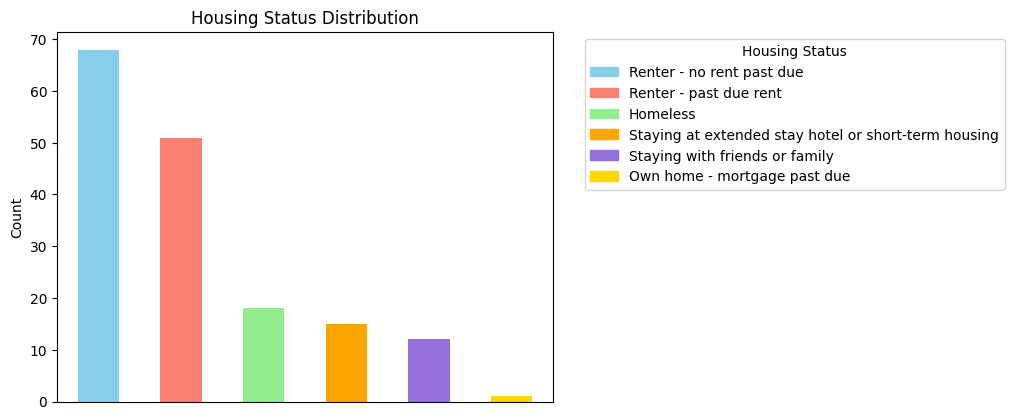

In [101]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Create an appropriate visualization.
colors = ['skyblue', 'salmon', 'lightgreen', 'orange', 'mediumpurple', 'gold']
counts = df_cleaned['Housing_Status'].value_counts()
ax = counts.plot(kind='bar', color=colors[:len(counts)], title='Housing Status Distribution', ylabel='Count')
handles = [mpatches.Patch(color=colors[i], label=label) for i, label in enumerate(counts.index)]
ax.legend(handles=handles, title='Housing Status', bbox_to_anchor=(1.05, 1), loc='upper left')

# Remove x-axis ticks and labels
ax.set_xticks([])
ax.set_xlabel('')

**Which housing status is most common? What do you notice about the overall distribution?**

The most common housing status is "Renter - no rent past due" (68 individuals), followed closely by "Renter - past due rent" (51 individuals).

Looking at the overall distribution, the vast majority of the people in this dataset are renters. A significant, though smaller, portion of the population is either homeless, staying in temporary housing (extended stay hotels), or staying with friends/family. Only one individual in the entire dataset owns a home.

11. How does monthly housing cost vary across housing situations?

In [82]:
# Compare Monthly_Housing_Cost across Housing_Status.
df_cleaned.groupby('Housing_Status')['Monthly_Housing_Cost'].mean()

,Monthly_Housing_Cost
Housing_Status,
Homeless,50.057778
Own home - mortgage past due,1376.020000
Renter - no rent past due,596.082662
Renter - past due rent,917.470784
Staying at extended stay hotel or short-term housing,740.867333
Staying with friends or family,255.835250


Text(0.5, 0, '')

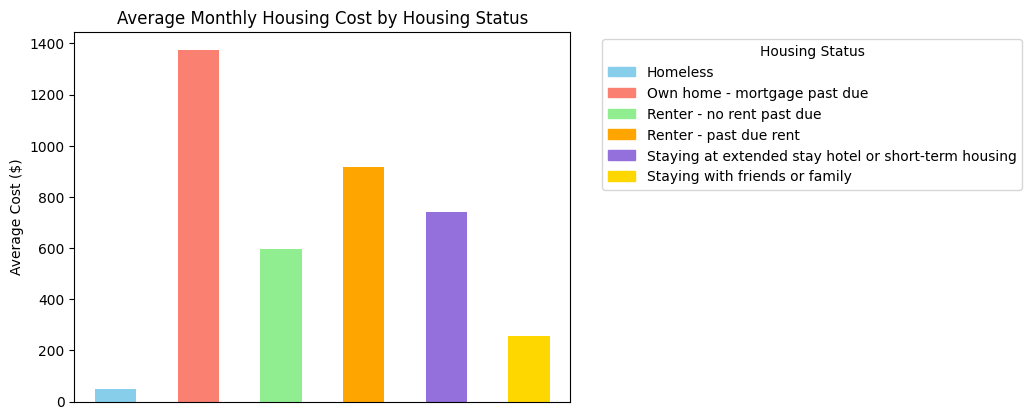

In [102]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Use a suitable summary and/or visualization.
colors = ['skyblue', 'salmon', 'lightgreen', 'orange', 'mediumpurple', 'gold']
means = df_cleaned.groupby('Housing_Status')['Monthly_Housing_Cost'].mean()
ax = means.plot(kind='bar', color=colors[:len(means)], title='Average Monthly Housing Cost by Housing Status', ylabel='Average Cost ($)')
handles = [mpatches.Patch(color=colors[i], label=label) for i, label in enumerate(means.index)]
ax.legend(handles=handles, title='Housing Status', bbox_to_anchor=(1.05, 1), loc='upper left')

# Remove x-axis ticks and labels
ax.set_xticks([])
ax.set_xlabel('')

**What pattern do you notice? Be careful when interpreting zero housing cost. Explain why.**

Pattern: Renters who are past due on their rent have noticeably higher average monthly housing costs (about  917) compared to renters who are current on their rent (about 596). The single homeowner in the dataset has the highest cost ($1,376), while those who are homeless or staying with friends/family have the lowest average costs, as expected.

Interpreting Zero: We must be careful with zero housing costs because in this dataset, a $0 value is usually not "missing" or "bad" data. Instead, it accurately represents people who legitimately do not pay rent (such as those who are homeless or staying with family for free). Including these valid zeros drastically lowers the average for those groups. It reflects their true living situation, but you shouldn't confuse it with the typical cost of actually renting an apartment or owning a home.

12. Is utility disconnection risk associated with a different LG&E bill pattern?

In [84]:
# Compare Monthly_LGE_Bill for people with different Utility_Disconnection_Risk values.
df_cleaned.groupby('Utility_Disconnection_Risk')['Monthly_LGE_Bill'].mean()

,Monthly_LGE_Bill
Utility_Disconnection_Risk,
Maybe,205.700000
No,98.491575
Yes,1408.425500


Text(0.5, 0, '')

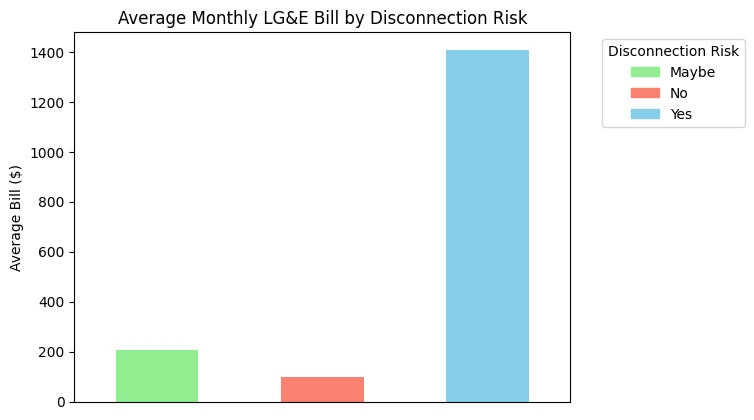

In [103]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Create an appropriate visualization.
colors = ['lightgreen', 'salmon', 'skyblue']
means = df_cleaned.groupby('Utility_Disconnection_Risk')['Monthly_LGE_Bill'].mean()
ax = means.plot(kind='bar', color=colors[:len(means)], title='Average Monthly LG&E Bill by Disconnection Risk', ylabel='Average Bill ($)')
handles = [mpatches.Patch(color=colors[i], label=label) for i, label in enumerate(means.index)]
ax.legend(handles=handles, title='Disconnection Risk', bbox_to_anchor=(1.05, 1), loc='upper left')

# Remove x-axis ticks and labels
ax.set_xticks([])
ax.set_xlabel('')

**Describe what you observe. Do not claim that one variable causes the other.**

I observe that individuals who report being at risk of utility disconnection ("Yes") have a much higher average monthly LG&E bill (over  1,400) compared to those who are not at risk (about 98) or those who might be at risk (about $206). There is a strong association between having a very high utility bill and being at risk for disconnection.

13. What does transportation need look like for people with and without a car?

Has_Car
No     3.265823
Yes    1.697674
Name: Transportation_Need_Score, dtype: float64


Text(0.5, 0, '')

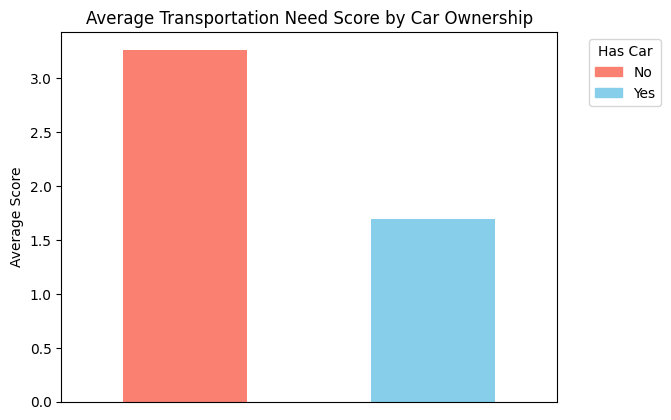

In [104]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Compare Transportation_Need_Score by Has_Car.
print(df_cleaned.groupby('Has_Car')['Transportation_Need_Score'].mean())

# Visualization for Transportation Need by Car Ownership
colors = ['salmon', 'skyblue']
means = df_cleaned.groupby('Has_Car')['Transportation_Need_Score'].mean()
ax = means.plot(kind='bar', color=colors[:len(means)], title='Average Transportation Need Score by Car Ownership', ylabel='Average Score')
handles = [mpatches.Patch(color=colors[i], label=label) for i, label in enumerate(means.index)]
ax.legend(handles=handles, title='Has Car', bbox_to_anchor=(1.05, 1), loc='upper left')

# Remove x-axis ticks and labels
ax.set_xticks([])
ax.set_xlabel('')

14. How is bus use distributed?

Bus_Use
Never        65
Often        47
Sometimes    35
Rarely       18
Name: count, dtype: int64


Text(0.5, 0, '')

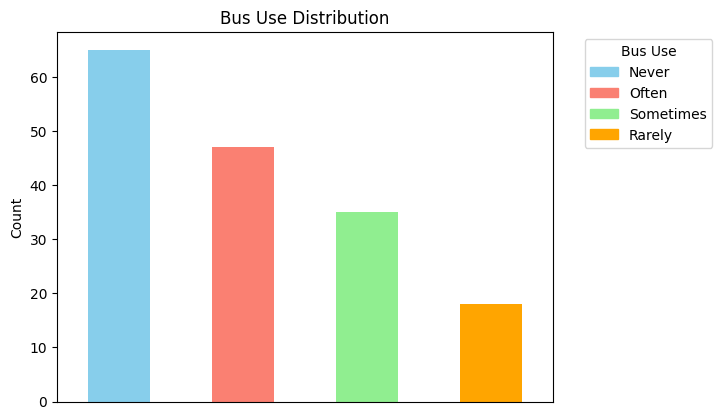

In [100]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Create a frequency table and visualization for Bus_Use.
print(df_cleaned['Bus_Use'].value_counts())

colors = ['skyblue', 'salmon', 'lightgreen', 'orange']
counts = df_cleaned['Bus_Use'].value_counts()
ax = counts.plot(kind='bar', color=colors[:len(counts)], title='Bus Use Distribution', ylabel='Count')
handles = [mpatches.Patch(color=colors[i], label=label) for i, label in enumerate(counts.index)]
ax.legend(handles=handles, title='Bus Use', bbox_to_anchor=(1.05, 1), loc='upper left')

# Remove x-axis ticks and labels
ax.set_xticks([])
ax.set_xlabel('')

**What additional variable would you compare with Bus_Use if you wanted to understand transportation needs better? Why?**

I would compare Bus_Use with Transportation_Need_Score. This would help us understand whether people who rely on the bus system still experience high transportation needs, or if the bus is effectively meeting their needs. For example, if frequent bus riders still report a very high transportation need score, it might suggest that the bus routes, schedules, or reliability are inadequate for their daily lives.

In [88]:
# Map Bus_Use to a numeric ordinal scale
bus_use_mapping = {'Never': 0, 'Rarely': 1, 'Sometimes': 2, 'Often': 3}
df_cleaned['Bus_Use_Numeric'] = df_cleaned['Bus_Use'].map(bus_use_mapping)

# Calculate the Pearson correlation
correlation = df_cleaned['Bus_Use_Numeric'].corr(df_cleaned['Transportation_Need_Score'])
print(f"Correlation between Bus_Use and Transportation_Need_Score: {correlation:.4f}")

Correlation between Bus_Use and Transportation_Need_Score: 0.3526


Since Bus_Use is a categorical variable (text), we first need to map it to numbers (Never = 0, Rarely = 1, Sometimes = 2, Often = 3) before calculating the correlation. I will add a code cell to do this and calculate the correlation.

The code executed successfully! The Pearson correlation between Bus_Use and Transportation_Need_Score is 0.3584.

This indicates a moderate positive correlation. It means that, generally, as a person's bus use increases (from Never to Often), their reported transportation need score also tends to increase. This supports the idea that frequent bus riders in this dataset are still experiencing transportation needs or challenges.

# Part 4 – Your Question

Now that you have worked through the guided exploration, ask ONE question of your own. Your question must be answerable using variables in this dataset and should investigate something you genuinely noticed or became curious about.

**15. What is your question?**

Question: Since we cannot do a soft credit pull, can we identify individuals who are at high 'financial risk' by seeing if people with an Eviction Record have higher total monthly basic expenses (Housing + LG&E + Water)?

Why: I was curious about assessing financial risk or how burdened their spending is. Because we lack credit scores, looking at total monthly expenses alongside distress indicators (like an eviction history) acts as a proxy for financial risk.

Variables: Eviction_Record, Monthly_Housing_Cost, Monthly_LGE_Bill, Monthly_Water_Bill.

Average Total Monthly Basic Cost by Eviction Record:
Eviction_Record
No     1146.858334
Yes     915.689324
Name: Total_Monthly_Basic_Cost, dtype: float64




<Axes: title={'center': 'Total Monthly Basic Costs vs. Eviction Record'}, xlabel='Has Eviction Record?', ylabel='Average Total Cost ($)'>

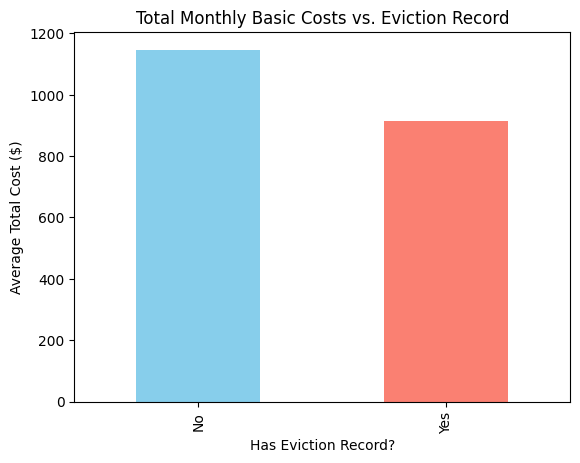

In [89]:
# Calculate total monthly basic costs (Housing + Utilities)
df_cleaned['Total_Monthly_Basic_Cost'] = df_cleaned['Monthly_Housing_Cost'] + df_cleaned['Monthly_LGE_Bill'] + df_cleaned['Monthly_Water_Bill']

# Compare average total costs by eviction record
cost_by_eviction = df_cleaned.groupby('Eviction_Record')['Total_Monthly_Basic_Cost'].mean()
print("Average Total Monthly Basic Cost by Eviction Record:")
print(cost_by_eviction)
print("\n")

# Visualize the findings
cost_by_eviction.plot(kind='bar', color=['skyblue', 'salmon', 'lightgray'],
                      title='Total Monthly Basic Costs vs. Eviction Record',
                      ylabel='Average Total Cost ($)', xlabel='Has Eviction Record?')

**16. What does the data tell you?**

Based on the bar chart and grouped data calculated above, the data tells us that individuals with a confirmed Eviction Record ('Yes') actually have the lowest average Total Monthly Basic Cost ( 893.89)compared to those without an eviction record ( 1,146.86).

This suggests that rather than having higher current living expenses, people who have been evicted may currently be in unstable living situations that cost less out-of-pocket. As we discovered earlier, individuals who are homeless or staying with friends/family report $0 for housing costs, which heavily drives down the average total expense for the group with eviction histories.

**17. What is your overall finding?**

Overall Finding: The most important finding is that having an eviction record is associated with lower current basic monthly expenses, likely because those individuals are in temporary, unpaid housing situations rather than standard rental arrangements.

Why it matters: This matters because it highlights that a low monthly expense does not always indicate financial stability or low risk. In this community dataset, extremely low expenses can actually be a strong indicator of severe housing distress and displacement.

Limitation: A major limitation of this analysis is that we cannot conclude causation. We do not know if the eviction directly caused their current low-expense (and potentially homeless) status, or if an underlying financial crisis caused both the eviction and the inability to afford current housing. Additionally, this proxy only looks at basic utility/housing costs, missing other types of debt.